In [25]:
import pandas as pd

jobs = pd.read_csv("jobs/job_descriptions.csv", nrows=6000)
jobs.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [26]:
jobs['Preference']# Colonnes sélectionnées pour le matching CV ↔ Job
selected_columns = [
    "Job Title",
    "Job Description",
    "skills",
    "Role",
    "Responsibilities",
    "Qualifications",
    "Company"
]


jobs_precis = jobs[selected_columns].copy()
jobs_precis.head()

,Job Title,Job Description,skills,Role,Responsibilities,Qualifications,Company
0,Digital Marketing Specialist,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte...",Social Media Manager,"Manage and grow social media accounts, create ...",M.Tech,Icahn Enterprises
1,Web Developer,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g...",Frontend Web Developer,"Design and code user interfaces for websites, ...",BCA,PNC Financial Services Group
2,Operations Manager,Quality Control Managers establish and enforce...,Quality control processes and methodologies St...,Quality Control Manager,Establish and enforce quality control standard...,PhD,United Services Automobile Assn.
3,Network Engineer,"Wireless Network Engineers design, implement, ...",Wireless network design and architecture Wi-Fi...,Wireless Network Engineer,"Design, configure, and optimize wireless netwo...",PhD,Hess
4,Event Manager,A Conference Manager coordinates and manages c...,Event planning Conference logistics Budget man...,Conference Manager,Specialize in conference and convention planni...,MBA,Cairn Energy


In [27]:

jobs_precis["job_text"] = (
    jobs_precis["Job Title"].fillna("") + " " +
    jobs_precis["Job Description"].fillna("") + " " +
    jobs_precis["skills"].fillna("") + " " +
    jobs_precis.get("Role", "").fillna("") + " " +
    jobs_precis.get("Responsibilities", "").fillna("") + " " +
    jobs_precis.get("Qualifications", "").fillna("") + " " +
    jobs_precis.get("Company", "").fillna("")
)

jobs_precis[["Job Title", "job_text"]].head()

,Job Title,job_text
0,Digital Marketing Specialist,Digital Marketing Specialist Social Media Mana...
1,Web Developer,Web Developer Frontend Web Developers design a...
2,Operations Manager,Operations Manager Quality Control Managers es...
3,Network Engineer,Network Engineer Wireless Network Engineers de...
4,Event Manager,Event Manager A Conference Manager coordinates...


In [28]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())
    return text

jobs_precis['job_text'] = jobs_precis['job_text'].apply(preprocess_text)

jobs_precis[['Job Title', 'job_text']].head()

,Job Title,job_text
0,Digital Marketing Specialist,digital marketing specialist social media mana...
1,Web Developer,web developer frontend web developers design a...
2,Operations Manager,operations manager quality control managers es...
3,Network Engineer,network engineer wireless network engineers de...
4,Event Manager,event manager a conference manager coordinates...


In [29]:
import PyPDF2
import os

cv_folder = "./cv"
cv_texts = {}

for root, dirs, files in os.walk(cv_folder):
    for file in files:
        if file.endswith(".pdf"):
            file_path = os.path.join(root, file)
            pdf = PyPDF2.PdfReader(file_path)
            text = ""
            for page in pdf.pages:
                text += page.extract_text() or "" 
           
            cv_texts[file_path] = text

print(f"Nombre de CV extraits : {len(cv_texts)}")

Nombre de CV extraits : 2590


In [30]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())
    return text


cv_texts_clean = {}
for path, text in cv_texts.items():
    cv_texts_clean[path] = preprocess_text(text)


In [31]:
from gensim.models.doc2vec import TaggedDocument

# --- Jobs ---
tagged_jobs = []
for i, text in enumerate(jobs_precis['job_text']):
    words = text.split()  # tokenization simple
    tagged_jobs.append(TaggedDocument(words=words, tags=[f'JOB_{i}']))

# --- CV ---
tagged_cvs = []
for i, text in enumerate(cv_texts_clean.values()):
    words = text.split()
    tagged_cvs.append(TaggedDocument(words=words, tags=[f'CV_{i}']))

# Vérification
#print("Exemple TaggedDocument job : ", tagged_jobs[0])
#print("Exemple TaggedDocument CV : ", tagged_cvs[0])

In [32]:
from gensim.models import Doc2Vec


all_tagged = tagged_jobs + tagged_cvs
model = Doc2Vec(vector_size=100, window=5, min_count=2, workers=4, epochs=40)
model.build_vocab(all_tagged)
print(f"Taille du vocabulaire : {len(model.wv.key_to_index)}") 

model.train(all_tagged, total_examples=model.corpus_count, epochs=model.epochs)

Taille du vocabulaire : 3642


In [33]:
from gensim.models import Doc2Vec


all_tagged = tagged_jobs + tagged_cvs
model = Doc2Vec(vector_size=100, window=5, min_count=2, workers=4, epochs=40)
model.build_vocab(all_tagged)
model.train(all_tagged, total_examples=model.corpus_count, epochs=model.epochs)


model.save("doc2vec_model_cv_job")
print("Modèle Doc2Vec entraîné et sauvegardé !")

Modèle Doc2Vec entraîné et sauvegardé !


In [ ]:
# Pour évaluer la qualité du modèle le prof a demande de créer un jeu de test annoté c'est à dire on dit si 
# le matching entre un cv et une offre est pertinente et pas pertinent . il a dit de le faire pour top10 cv 
# un truc comme ça 

In [37]:
# Top 10 jobs pour le test
job_texts_test = jobs_precis['job_text'][:10]

# Inférer vecteurs jobs
job_vectors = [model.infer_vector(j.split()) for j in job_texts_test]

# Inférer vecteurs CV
cv_vectors = [model.infer_vector(cv.split()) for cv in cv_texts_clean.values()]
cv_names = list(cv_texts_clean.keys())

In [38]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

scores_df = pd.DataFrame(index=cv_names,
                         columns=[f"Job_{i}" for i in range(len(job_vectors))])

for i, cv_vec in enumerate(cv_vectors):
    for j, job_vec in enumerate(job_vectors):
        score = cosine_similarity([cv_vec], [job_vec])[0][0]
        scores_df.iloc[i, j] = score

print(scores_df.head())

                                         Job_0     Job_1     Job_2     Job_3  \
./cv/anti-cv.pdf                      0.131385  0.064048  0.168693  0.233044   
./cv/CV_Roger_KOUAKOU_data_final.pdf    0.2533  0.078518   0.10327  0.265698   
./cv/DevOps/Image_50.pdf             -0.003839 -0.065485  0.016151 -0.130426   
./cv/DevOps/Image_35.pdf              0.006156  0.036489  0.014547 -0.008482   
./cv/DevOps/Image_76.pdf              0.125524 -0.025567  0.152563  0.151489   

                                         Job_4     Job_5     Job_6     Job_7  \
./cv/anti-cv.pdf                      0.278193  0.272886  0.294851  0.179681   
./cv/CV_Roger_KOUAKOU_data_final.pdf  0.141424   0.25254  0.333817  0.236508   
./cv/DevOps/Image_50.pdf              -0.05169 -0.066993 -0.054865 -0.109102   
./cv/DevOps/Image_35.pdf             -0.031738  0.048229   0.17809  0.004897   
./cv/DevOps/Image_76.pdf              0.040067  0.062418  0.059916  0.114474   

                                      

In [39]:
top10_per_job = {}
for j in scores_df.columns:
    top10_per_job[j] = scores_df[j].astype(float).sort_values(ascending=False).head(10)

In [47]:
import pandas as pd

# Construire le DataFrame
annotated_df = pd.DataFrame(rows)

# Convertir la colonne Score en float
annotated_df['Score'] = annotated_df['Score'].astype(float)

# Trier par Job, puis par Score décroissant
annotated_df_sorted = annotated_df.sort_values(by=['Job', 'Score'], ascending=[True, False]).reset_index(drop=True)

# Vérifier les 15 premiers
annotated_df_sorted.head(15)

,Job,CV,Score,Pertinent
0,Job_0,./cv/Arts/Image_71.pdf,0.305595,
1,Job_0,./cv/Business Analyst/Image_13.pdf,0.295674,
2,Job_0,./cv/Business Analyst/Image_94.pdf,0.266324,
3,Job_0,./cv/.ipynb_checkpoints/CV_Roger_KOUAKOU_data_...,0.263313,
4,Job_0,./cv/Public relations/Image_59.pdf,0.262829,
5,Job_0,./cv/ETL developper/Image_69.pdf,0.258049,
6,Job_0,./cv/DotNET/Image_27.pdf,0.257130,
7,Job_0,./cv/BPO/Image_24.pdf,0.253940,
8,Job_0,./cv/CV_Roger_KOUAKOU_data_final.pdf,0.253300,
9,Job_0,./cv/Mechanical Engineer/Image_41.pdf,0.251743,


In [48]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. Préparer les vecteurs ---
# job_vectors et cv_vectors sont déjà calculés avec Doc2Vec
# cv_names = list(cv_texts_clean.keys())
# job_names = [f"Job_{i}" for i in range(len(job_vectors))]

# Construire le DataFrame des scores
scores_df = pd.DataFrame(index=cv_names, columns=job_names)

for i, cv_vec in enumerate(cv_vectors):
    for j, job_vec in enumerate(job_vectors):
        score = cosine_similarity([cv_vec], [job_vec])[0][0]
        scores_df.iloc[i, j] = score

# --- 2. Extraire les compétences clés du job et CV avec NER (déjà défini) ---
# skills_in_job_dict[job_name] = set of skills
# skills_in_cv_dict[cv_name] = set of skills

# --- 3. Annoter Pertinent / Non Pertinent ---
annotated_rows = []

for job_name in scores_df.columns:
    # Moyenne des scores pour ce job
    job_scores = scores_df[job_name].astype(float)
    threshold = job_scores.mean()

    for cv_name in scores_df.index:
        score = float(scores_df.loc[cv_name, job_name])
        # Vérification des compétences : au moins 50% des skills de l'offre présentes dans le CV
        skills_job = skills_in_job_dict[job_name]
        skills_cv = skills_in_cv_dict[cv_name]
        if len(skills_job) > 0:
            skills_match_ratio = len(skills_job & skills_cv) / len(skills_job)
        else:
            skills_match_ratio = 0

        # Définition du label
        if score > threshold and skills_match_ratio >= 0.5:
            pertinent = "Pertinent"
        else:
            pertinent = "Non Pertinent"

        annotated_rows.append({
            "Job": job_name,
            "CV": cv_name,
            "Score": score,
            "Skills Match (%)": round(skills_match_ratio * 100, 2),
            "Pertinent": pertinent
        })

# --- 4. Créer le DataFrame final ---
annotated_df = pd.DataFrame(annotated_rows)

# Trier par Job et Score décroissant
annotated_df.sort_values(by=['Job', 'Score'], ascending=[True, False], inplace=True)
annotated_df.reset_index(drop=True, inplace=True)

# Vérifier
print(annotated_df.head(20))

NameError: name 'job_names' is not defined

In [34]:
import PyPDF2
import os
import re

# Fonction de prétraitement
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())
    return text


cv_test_folder = "./cv_pour_test"
cv_texts_test = {}

for file in os.listdir(cv_test_folder):
    if file.endswith(".pdf"):
        file_path = os.path.join(cv_test_folder, file)
        pdf = PyPDF2.PdfReader(file_path)
        text = ""
        for page in pdf.pages:
            text += page.extract_text() or ""
        # Prétraiter le texte directement
        cv_texts_test[file] = preprocess_text(text)

print(f"{len(cv_texts_test)} CV extraits et prétraités pour test.")
job_text = input("description du job : ")

1 CV extraits et prétraités pour test.


description du job :  Who's Rollee  Rollee is building the next-gen credit bureau to make financial services accessible for everyone. We work with auto lenders, banks, insurance companies, and many other businesses to streamline their underwriting process. You can be an Uber driver, a Tiktoker or thriving as a freelance consultant; we make your income data accessible, readable and in the proper context for lenders so you get what you deserve.  What's the role  We are looking for a Product Data Scientist Intern to join our team during 6 months.  You’ll sit at the intersection of Product and Data, ensuring that Rollee’s data is accurate, reliable, and truly valuable for our customers Working with various datasets to extract meaningful information with a business approach Running business QA on datasets we collect Structuring rough data into exploitable features available through our API Developing internal and external business intelligence models Teaming up with Product, Business and Te

In [35]:
job_text_clean = preprocess_text(job_text)
print(job_text_clean)

who s rollee rollee is building the next gen credit bureau to make financial services accessible for everyone we work with auto lenders banks insurance companies and many other businesses to streamline their underwriting process you can be an uber driver a tiktoker or thriving as a freelance consultant we make your income data accessible readable and in the proper context for lenders so you get what you deserve what s the role we are looking for a product data scientist intern to join our team during months you ll sit at the intersection of product and data ensuring that rollee s data is accurate reliable and truly valuable for our customers working with various datasets to extract meaningful information with a business approach running business qa on datasets we collect structuring rough data into exploitable features available through our api developing internal and external business intelligence models teaming up with product business and tech to implement data driven strategies you

cv_english.pdf → Score de matching : 0.50


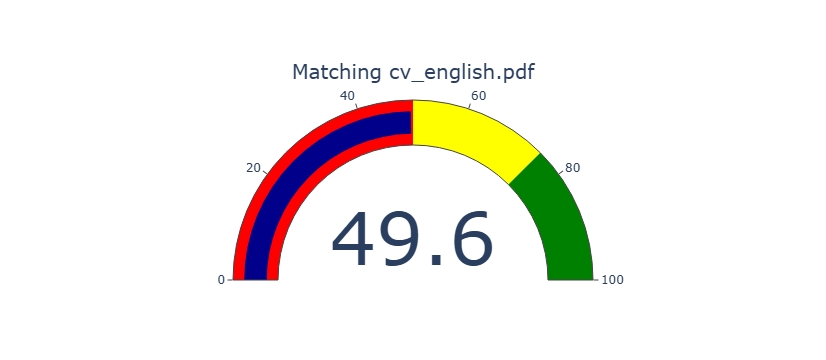

In [36]:
from sklearn.metrics.pairwise import cosine_similarity
import plotly.graph_objects as go

job_vector = model.infer_vector(job_text_clean.split())

    
for fname, cv_text in cv_texts_test.items():
    cv_vector = model.infer_vector(cv_text.split())
    score = cosine_similarity([cv_vector], [job_vector])[0][0]

   
    print(f"{fname} → Score de matching : {score:.2f}")


    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=score * 100,  # convertir en %
        title={'text': f"Matching {fname}"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "darkblue"},
            'steps': [
                {'range': [0, 50], 'color': "red"},
                {'range': [50, 75], 'color': "yellow"},
                {'range': [75, 100], 'color': "green"}],
        }
    ))

    fig.show()

In [15]:
import spacy


nlp = spacy.load("en_core_web_sm")


job_doc = nlp(job_text_clean)
cv_doc = nlp(cv_texts_test["cv_english.pdf"])


job_entities = set([ent.text.lower() for ent in job_doc.ents])
cv_entities = set([ent.text.lower() for ent in cv_doc.ents])


missing_in_cv = job_entities - cv_entities
print("Entités présentes dans le job mais pas dans le CV :", missing_in_cv)

Entités présentes dans le job mais pas dans le CV : {'first', 'hour', 'working hours', 'months', 'rollee s data', 'our day to day', 'first day'}


In [16]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

model_name = "Nucha/Nucha_SkillNER_BERT"


tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)


ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Texte à analyser
job_text_clean  
cv_text = cv_texts_test["cv_english.pdf"] 


job_entities = ner_pipeline(job_text_clean)
skills_in_job = set([ent['word'].lower() for ent in job_entities if ent['entity_group'] in ["HSKILL","SSKILL"]])


cv_entities = ner_pipeline(cv_text)
skills_in_cv = set([ent['word'].lower() for ent in cv_entities if ent['entity_group'] in ["HSKILL","SSKILL"]])


missing_skills = skills_in_job - skills_in_cv

print("Compétences détectées dans le job :", skills_in_job)
print("Compétences présentes dans le CV :", skills_in_cv)
print("Compétences manquantes dans le CV :", missing_skills)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Compétences détectées dans le job : {'git', 'machine learning', 'sql', 'ai', 'english', 'api', 'data science', 'conversation', 'business intelligence', 'python', 'computer science'}
Compétences présentes dans le CV : {'github com', 'solving experience', 'english', 'nl', '##p', 'power', 'raw', 'computer science', 'problem', 'machine', '##ive modeling and', 'git', 'machine learning', 'sql', 'business intelligence', '##s', 'r', 'data analysis', 'ai', '##work', 'prototyping for', 'business', 'apis', 'python', '##au', 'ml'}
Compétences manquantes dans le CV : {'data science', 'conversation', 'api'}


In [ ]:
# le prof a dit que ce modèle d'extraction était plutôt bon mais par exemple 
# on pourrait évaluer sa qualité d'extraction
# c'est à dire extraire les compétences d'un cv via la bibliothèque python et faire une comparaison avec les compétences
# extraites via le modèle pré-entraîné comme ça on peut savoir si le modèle est adapté au projet